In [1]:
# Set working directory
import os
os.chdir("../../")
!pwd

/home/labs/barkailab/joshuabu/files_for_publication


In [2]:
# Configure file paths

# Footprint chec-seq signal files
erg_fp_path = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ERG_raw_windows.csv"
atf1_fp_path = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ATF1_raw_windows.csv"

# Nucleosome score signal files (matching motif occurrences from footprint file)
erg_nuc_path = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/nuc_scores/ERG_nucleosome_windows.csv"
atf1_nuc_path = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/nuc_scores/ATF1_nucleosome_windows.csv"

# Available for download online from HOCOMOCO v12
gabpa_pfm = "../pfm/GABPA.H12CORE.0.PSM.A.pfm"
batf3_pfm = "../pfm/BATF3.H12CORE.2.SM.B.pfm"

## Imports

In [3]:
import logomaker as lm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from typing import Optional, Sequence, Tuple

## Helper Functions

In [4]:
# Get the position columns that exist in the requested range
def _pos_cols_in(df: pd.DataFrame, rng: Sequence[int]) -> list[str]:
    cols = [f"pos_{i}" for i in rng]
    return [c for c in cols if c in df.columns]


# Sort rows by the central signal window and keep the requested plotting window
def _sorted_and_window(df: pd.DataFrame, width: int) -> tuple[pd.DataFrame, list[str]]:
    if width < 1:
        raise ValueError("width must be >= 1")

    sort_range = range(-25, 26)
    heat_range = range(-width, width + 1)

    sort_cols = _pos_cols_in(df, sort_range)
    if len(sort_cols) == 0:
        raise ValueError("No sorting columns found (expected 'pos_-25'..'pos_25').")

    sort_sum = df[sort_cols].sum(axis=1)
    df_sorted = df.assign(_sum=sort_sum).sort_values("_sum", ascending=False).drop(columns="_sum")

    heat_cols = _pos_cols_in(df_sorted, heat_range)
    if len(heat_cols) == 0:
        raise ValueError(f"No heatmap columns found for width={width}.")

    return df_sorted, heat_cols

## Data Loading

In [5]:
# Load footprint signal matrices
erg_fp_df = pd.read_csv(erg_fp_path, index_col=0)
atf1_fp_df = pd.read_csv(atf1_fp_path, index_col=0)

# Load nucleosome score matrices
erg_nuc_df = pd.read_csv(erg_nuc_path, index_col=0)
atf1_nuc_df = pd.read_csv(atf1_nuc_path, index_col=0)

## Plotting

In [6]:
# Plot the top and bottom motif-centered averages with nucleosome signal
def plot_top_and_bottom_N_average_line_with_nuc(
    df: pd.DataFrame,
    nuc_df: pd.DataFrame,
    *,
    top_n: int = 200,
    width: int = 100,
    dropna: bool = False,
    figsize: Tuple[float, float] = (3.5, 2),
    title: Optional[str] = None,
    linewidth: float = 1.5,
    pfm_path: Optional[str] = None,
    logo_height: float = 0.09,
    logo_gap: float = 0.015,
) -> plt.Figure:

    # Sort rows and extract position columns
    df_sorted, heat_cols = _sorted_and_window(df, width)

    if dropna:
        df_sorted = df_sorted.dropna(subset=heat_cols)

    n = min(top_n, len(df_sorted))
    xs = np.array([int(c.split("_", 1)[1]) for c in heat_cols], dtype=int)

    # Top panel averages
    sub_top = df_sorted.iloc[:n][heat_cols]
    y_fp_top = sub_top.mean(axis=0, skipna=True).to_numpy()

    nuc_sub_top = nuc_df.loc[sub_top.index, heat_cols]
    y_nuc_top = nuc_sub_top.mean(axis=0, skipna=True).to_numpy()

    # Bottom panel averages
    sub_bot = df_sorted.iloc[-n:][heat_cols]
    y_fp_bot = sub_bot.mean(axis=0, skipna=True).to_numpy()

    nuc_sub_bot = nuc_df.loc[sub_bot.index, heat_cols]
    y_nuc_bot = nuc_sub_bot.mean(axis=0, skipna=True).to_numpy()

    # Build the stacked layout
    fig, ax_nuc_top = plt.subplots(
        2,
        1,
        sharex=True,
        figsize=(figsize[0], figsize[1] * 2),
        gridspec_kw={"hspace": 0.08},
    )
    ax_nuc_bot = ax_nuc_top[1]
    ax_nuc_top = ax_nuc_top[0]

    # Add footprint axes on top of the nucleosome axes
    ax_fp_top = ax_nuc_top.twinx()
    ax_fp_bot = ax_nuc_bot.twinx()

    ax_fp_top.patch.set_alpha(0.0)
    ax_fp_bot.patch.set_alpha(0.0)

    # Put nucleosome on the right
    for ax_nuc in (ax_nuc_top, ax_nuc_bot):
        ax_nuc.yaxis.set_label_position("right")
        ax_nuc.yaxis.tick_right()
        ax_nuc.spines["right"].set_visible(True)
        ax_nuc.spines["left"].set_visible(False)

    # Put footprint on the left
    for ax_fp in (ax_fp_top, ax_fp_bot):
        ax_fp.yaxis.set_label_position("left")
        ax_fp.yaxis.tick_left()
        ax_fp.spines["left"].set_visible(True)
        ax_fp.spines["right"].set_visible(False)

    # Draw the top nucleosome profile
    ax_nuc_top.set_ylim(bottom=0)
    ax_nuc_top.fill_between(xs, y_nuc_top, 0, color="tab:blue", alpha=0.1, zorder=0)
    ax_nuc_top.plot(xs, y_nuc_top, lw=1.2, color="gray", zorder=1)
    ax_nuc_top.set_ylabel("Mean. Nucleosome Score", rotation=270, labelpad=11)
    ax_nuc_top.tick_params(axis="y", colors="gray", labelsize=9)
    ax_nuc_top.set_xlim(xs.min(), xs.max())

    nuc_ylim_top = (0, np.nanmax(y_nuc_top) * 1.1 if np.isfinite(np.nanmax(y_nuc_top)) else 1.0)
    ax_nuc_top.set_ylim(*nuc_ylim_top)

    # Draw the top footprint profile
    ax_fp_top.axvline(0, ls="--", alpha=0.25, color="black", zorder=2)
    ax_fp_top.plot(xs, y_fp_top, lw=linewidth, color="black", zorder=3)
    ax_fp_top.set_ylabel("Med. Footprint Signal", color="black", labelpad=0)
    ax_fp_top.set_xlabel("Distance from motif")
    ax_fp_top.set_xlim(xs.min(), xs.max())
    ax_fp_top.tick_params(axis="y", labelsize=9)

    fp_ylim_top = ax_fp_top.get_ylim()

    # Draw the bottom nucleosome profile
    ax_nuc_bot.set_ylim(bottom=0)
    ax_nuc_bot.fill_between(xs, y_nuc_bot, 0, color="tab:blue", alpha=0.1, zorder=0)
    ax_nuc_bot.plot(xs, y_nuc_bot, lw=1.2, color="gray", zorder=1)
    ax_nuc_bot.set_ylabel("Med. Nucleosome Score", rotation=270, labelpad=11)
    ax_nuc_bot.tick_params(axis="y", colors="gray", labelsize=9)
    ax_nuc_bot.set_xlim(xs.min(), xs.max())

    # Draw the bottom footprint profile
    ax_fp_bot.axvline(0, ls="--", alpha=0.25, color="black", zorder=2)
    ax_fp_bot.plot(xs, y_fp_bot, lw=linewidth, color="black", zorder=3)
    ax_fp_bot.set_ylabel("Med. Footprint Signal", color="black", labelpad=0)
    ax_nuc_bot.set_xlabel("Distance from motif (bp)", fontsize=12)
    ax_fp_bot.set_xlim(xs.min(), xs.max())
    ax_fp_bot.tick_params(axis="y", labelsize=9)

    # Match both panels to the top-panel limits
    ax_nuc_bot.set_ylim(*nuc_ylim_top)
    ax_fp_bot.set_ylim(*fp_ylim_top)

    # Hide the y-axis labels and ticks
    for axis in (ax_nuc_top, ax_fp_top, ax_nuc_bot, ax_fp_bot):
        axis.tick_params(
            axis="y",
            which="both",
            left=False,
            right=False,
            labelleft=False,
            labelright=False,
        )
        axis.set_ylabel("")

    if title:
        fig.suptitle(title, fontsize=18, y=0.99)

    plt.subplots_adjust(
        left=0.14,
        right=0.86,
        bottom=0.12,
        top=0.92,
        hspace=0.2,
    )

    # Add the motif logo below the bottom panel
    if pfm_path is not None:
        plt.subplots_adjust(bottom=0.22)

        pos = ax_nuc_bot.get_position()

        logo_height = 0.11
        logo_gap = 0.11

        ax_logo = fig.add_axes([
            pos.x0 - 0.02,
            pos.y0 - logo_gap - logo_height,
            pos.width + 0.04,
            logo_height,
        ])

        lines = []
        with open(pfm_path, "r") as fh:
            for ln in fh:
                ln = ln.strip()
                if ln:
                    lines.append(ln)

        if lines and lines[0].startswith(">"):
            lines = lines[1:]

        vals = [list(map(float, ln.split())) for ln in lines]
        arr = np.asarray(vals, dtype=float)

        counts = pd.DataFrame(arr, columns=["A", "C", "G", "T"])
        probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
        ic_mat = lm.transform_matrix(probs, from_type="probability", to_type="information")

        lm.Logo(ic_mat, ax=ax_logo)

        ax_logo.set_xticks([])
        ax_logo.set_yticks([])
        ax_logo.set_xlabel("")
        ax_logo.set_ylabel("")

        p = ax_logo.get_position()
        ax_logo.set_position([p.x0 + 0.12, p.y0, p.width * 0.7, p.height])

    return fig

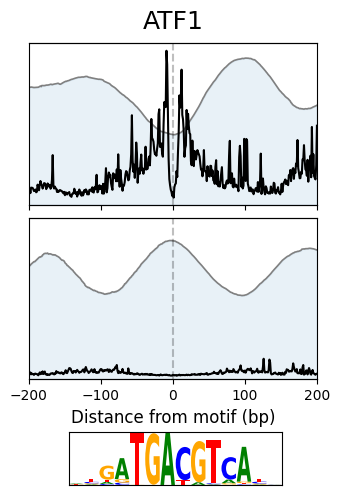

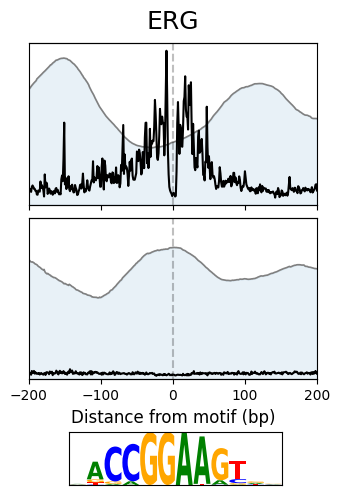

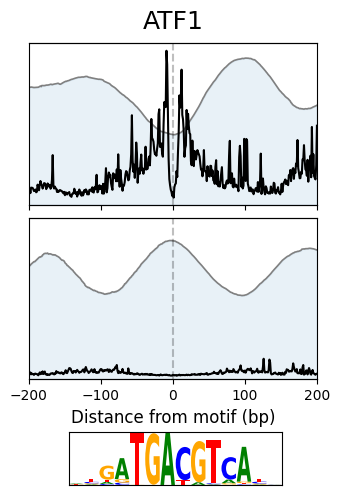

In [7]:
plot_top_and_bottom_N_average_line_with_nuc(
    df=erg_fp_df,
    nuc_df=erg_nuc_df,
    top_n=200,
    width=200,
    title="ERG",
    figsize=(4, 2.4),
    pfm_path=gabpa_pfm,
)

plot_top_and_bottom_N_average_line_with_nuc(
    df=atf1_fp_df,
    nuc_df=atf1_nuc_df,
    top_n=200,
    width=200,
    title="ATF1",
    figsize=(4, 2.4),
    pfm_path=batf3_pfm,
)